### Importing Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns             # optional, useful for EDA plots
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Defining Performance Metrics

In [2]:
# Metrics
def mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def r2(y_true, y_pred):
    return r2_score(y_true, y_pred)

### Loading dataset

In [8]:
# ===== Step 1: Load dataset & quick EDA =====
FNAME = "mobile_price.csv"   # change if necessary
TARGET_COL = "Price"

if not os.path.exists(FNAME):
    raise FileNotFoundError(f"Put your dataset CSV in the working directory and name it '{FNAME}' or change FNAME in the cell.")

df = pd.read_csv(FNAME)
print("Shape:", df.shape)
print("\nColumns and types:\n", df.dtypes)
print("\nFirst 5 rows:")
display(df.head())

Shape: (807, 8)

Columns and types:
 Ratings          float64
RAM              float64
ROM              float64
Mobile_Size      float64
Primary_Cam        int64
Selfi_Cam        float64
Battery_Power      int64
Price              int64
dtype: object

First 5 rows:


,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
0,4.3,4.0,128.0,6.00,48,13.0,4000,24999
1,3.4,6.0,64.0,4.50,48,12.0,4000,15999
2,4.3,4.0,4.0,4.50,64,16.0,4000,15000
3,4.4,6.0,64.0,6.40,48,15.0,3800,18999
4,4.5,6.0,128.0,6.18,35,15.0,3800,18999


### Handling Missing Values and displaying basic statistics

In [10]:
# Missing values
print("\nMissing values per column:")
print(df.isna().sum(),'\n')

# Basic statistics
print("Basic Statistics:")
display(df.describe().T)


Missing values per column:
Ratings          0
RAM              0
ROM              0
Mobile_Size      0
Primary_Cam      0
Selfi_Cam        0
Battery_Power    0
Price            0
dtype: int64 

Basic Statistics:


,count,mean,std,min,25%,50%,75%,max
Ratings,807.0,4.112639,0.367830,2.8,3.9,4.10,4.4,4.8
RAM,807.0,5.941760,2.056359,0.0,6.0,6.00,6.0,12.0
ROM,807.0,64.390335,53.868626,2.0,32.0,32.00,64.0,256.0
Mobile_Size,807.0,5.620660,3.957409,2.0,4.5,4.77,6.3,44.0
Primary_Cam,807.0,47.821561,11.155916,5.0,48.0,48.00,48.0,64.0
Selfi_Cam,807.0,8.868649,4.547254,0.0,8.0,8.00,12.0,23.0
Battery_Power,807.0,3278.859975,937.628801,1020.0,3000.0,3000.00,3800.0,6000.0
Price,807.0,14269.167286,23092.739983,479.0,984.0,1699.00,18994.5,153000.0


### Plotting histogram of target feature

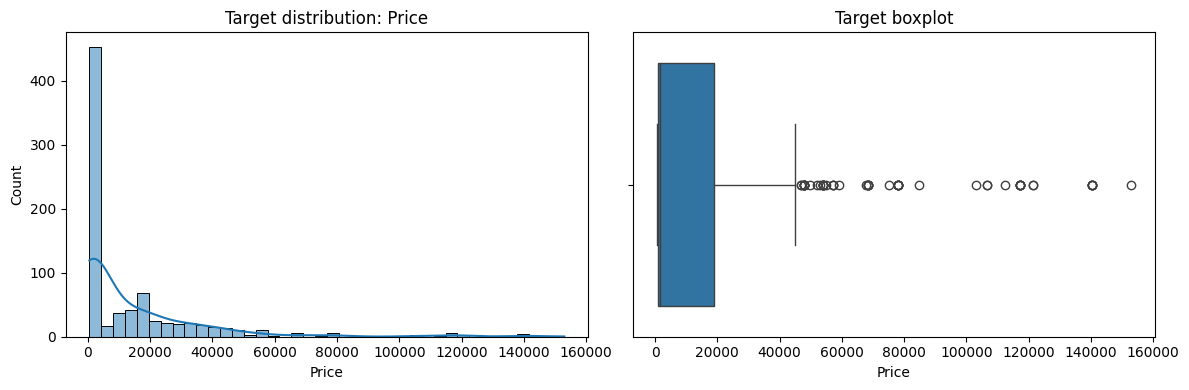

In [11]:
# Plot distributions for numeric features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COL in num_cols:
    num_cols.remove(TARGET_COL)

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
sns.histplot(df[TARGET_COL], kde=True).set_title("Target distribution: " + TARGET_COL)
plt.subplot(1,2,2)
sns.boxplot(x=df[TARGET_COL]).set_title("Target boxplot")
plt.tight_layout()

### Plotting correlation map

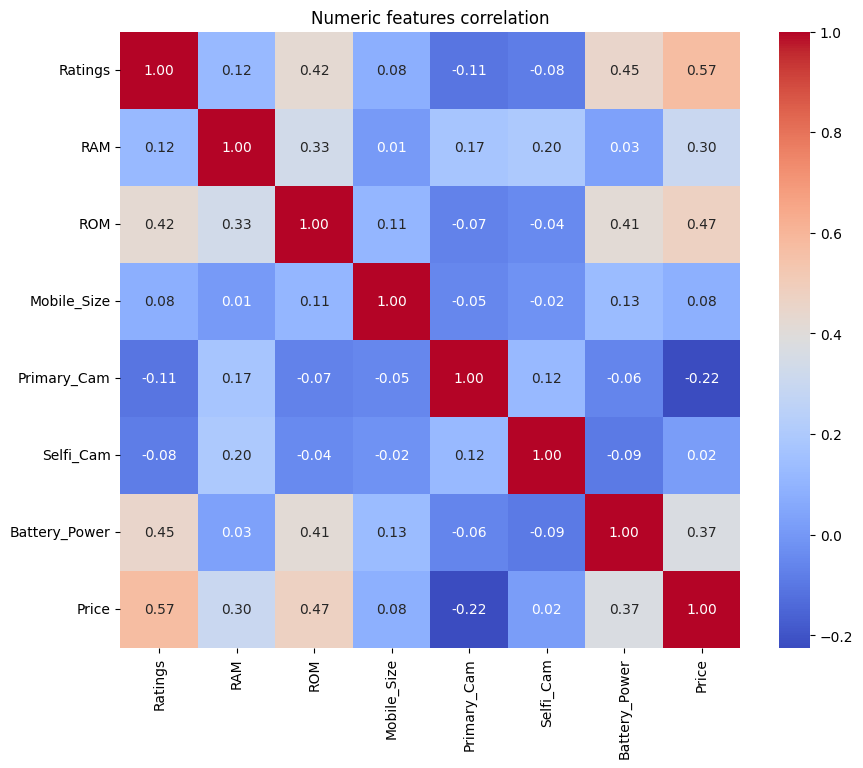

In [12]:
# Correlation heatmap (only numeric features)
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=False)
plt.title("Numeric features correlation")
plt.show()

### Plotting all features with target

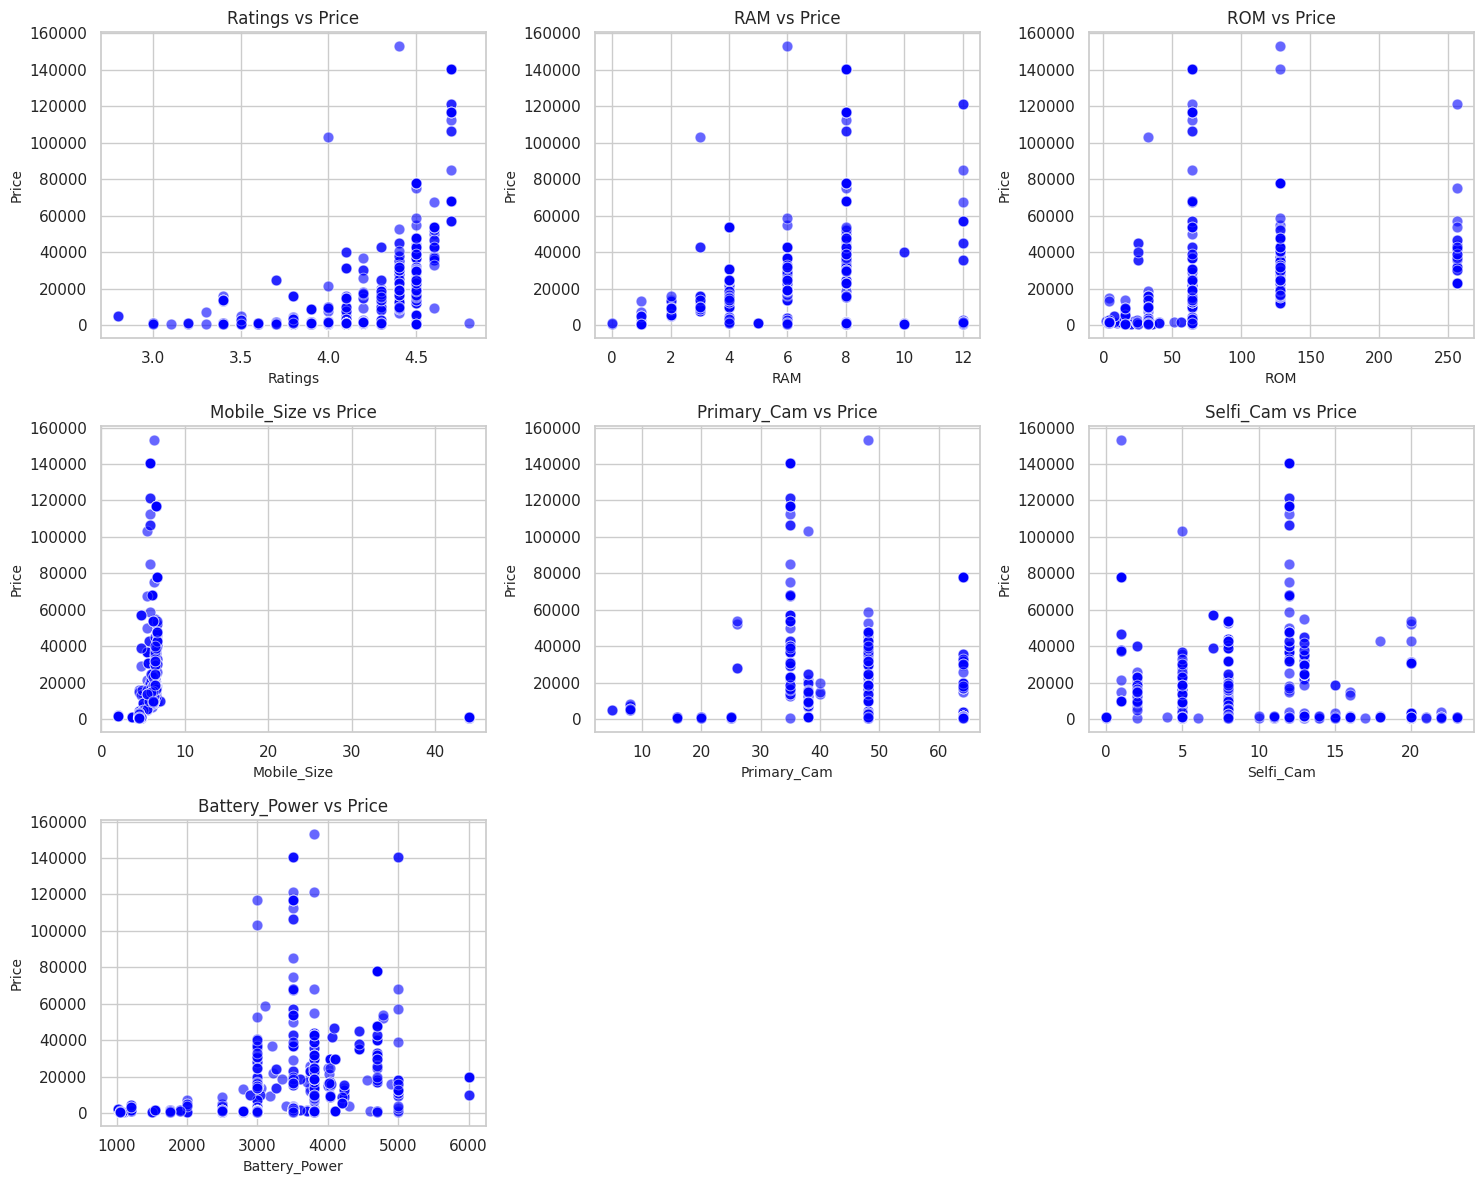

In [14]:
features = ["Ratings", "RAM", "ROM", "Mobile_Size", 
            "Primary_Cam", "Selfi_Cam", "Battery_Power"]

# 3. Set style
sns.set(style="whitegrid", palette="muted")

# 4. Plot all scatterplots with regression lines
plt.figure(figsize=(15, 12))

for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=df[feature], y=df["Price"], s=60, color="blue", alpha=0.6)
    #sns.regplot(x=df[feature], y=df["Price"], scatter=False, color="red")
    plt.xlabel(feature, fontsize=10)
    plt.ylabel("Price", fontsize=10)
    plt.title(f"{feature} vs Price", fontsize=12)

plt.tight_layout()
plt.show()

### Splitting final X and y

In [18]:
df = df.dropna(subset=[TARGET_COL])

X_df = df.drop(columns=[TARGET_COL]).copy()
y_df = df[[TARGET_COL]].copy()   # keep as DataFrame for shape clarity

print("Final feature count:", X_df.shape[1])
print("Examples of features:", X_df.columns.tolist()[:10])


Final feature count: 7
Examples of features: ['Ratings', 'RAM', 'ROM', 'Mobile_Size', 'Primary_Cam', 'Selfi_Cam', 'Battery_Power']


### Doing train/test split

In [19]:
# ===== Step 3: Train/test split and matrix construction =====
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(
    X_df, y_df, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Convert to numpy arrays
X_train = X_train_df.values.astype(float)    # shape: (n_train, d)
X_test  = X_test_df.values.astype(float)     # shape: (n_test, d)
y_train = y_train_df.values.astype(float)    # shape: (n_train, 1)
y_test  = y_test_df.values.astype(float)     # shape: (n_test, 1)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)


X_train shape: (645, 7)
X_test  shape: (162, 7)
y_train shape: (645, 1)
y_test  shape: (162, 1)


### Adiition of bias(intercept)

In [22]:
# Add bias (intercept) column
def add_bias(X):
    return np.hstack([np.ones((X.shape[0],1)), X])

X_train_b = add_bias(X_train)  # shape: (n_train, d+1)
X_test_b  = add_bias(X_test)   # shape: (n_test, d+1)

print("X_train_b shape (with bias):", X_train_b.shape)
print("Parameter theta shape should be:", (X_train_b.shape[1], 1)) 

X_train_b shape (with bias): (645, 8)
Parameter theta shape should be: (8, 1)


### Finding theta and intercept value using closed form solution

In [29]:
# ===== Step 4: Closed-form solution (normal equation) =====
def closed_form_theta(X_b, y, l2=0.0, regularize_bias=False):
    """
    Returns theta (d+1,1).
    If l2 > 0.0, performs ridge closed-form: theta = (X^T X + lambda * I)^(-1) X^T y
    regularize_bias=False -> do not regularize intercept (set corresponding I[0,0]=0)
    """
    n, d_plus_1 = X_b.shape
    A = X_b.T @ X_b
    if l2 > 0.0:
        I = np.eye(d_plus_1)
        if not regularize_bias:
            I[0,0] = 0.0
        A = A + l2 * I
    theta = np.linalg.pinv(A) @ (X_b.T @ y)
    return theta

# Fit ordinary least squares
theta_cf = closed_form_theta(X_train_b, y_train, l2=0.0)
print("Theta shape:", theta_cf.shape)
print("Intercept (theta0):", theta_cf[0,0])
print("First 5 weights:", theta_cf.flatten()[1:6])

Theta shape: (8, 1)
Intercept (theta0): -103323.53099980904
First 5 weights: [26416.6083058   2777.61247111    73.12751317   121.17996754
  -467.97064579]


### Predicting without standarization and regularization

In [30]:
# Predict
y_pred_test_cf = X_test_b @ theta_cf
y_pred_train_cf = X_train_b @ theta_cf

print("Closed-form Test RMSE:", rmse(y_test, y_pred_test_cf))
print("Closed-form Test R2:", r2(y_test, y_pred_test_cf))

Closed-form Test RMSE: 15471.18797732679
Closed-form Test R2: 0.43322813972495156


### Predicted vs Actual Plot

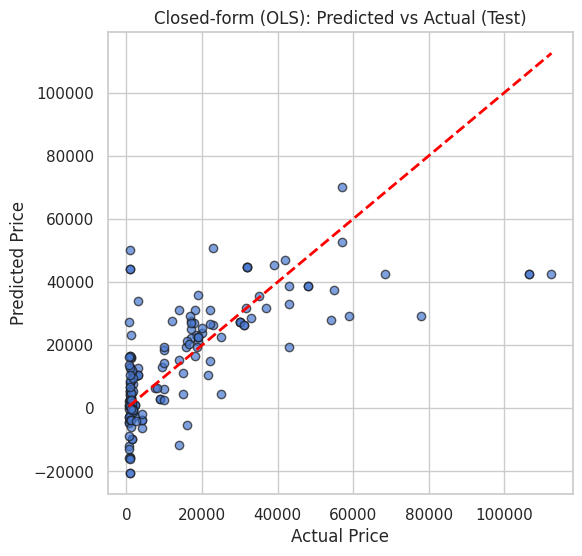

In [32]:
# Predicted vs Actual (Test set)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test_cf, alpha=0.7, edgecolor='k')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2)  # ideal line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Closed-form (OLS): Predicted vs Actual (Test)")
plt.grid(True)
plt.show()


### L2 Regularization without Standardization

In [ ]:
l2_lambda = 10   # try values like 1, 10, 100, 1000

theta_cf_l2_raw = closed_form_theta(X_train_b, y_train, l2=l2_lambda)
y_pred_test_cf_l2_raw  = X_test_b @ theta_cf_l2_raw
y_pred_train_cf_l2_raw = X_train_b @ theta_cf_l2_raw

print("Ridge (Raw) -> Test RMSE:", rmse(y_test, y_pred_test_cf_l2_raw))
print("Ridge (Raw) -> Test R2:", r2(y_test, y_pred_test_cf_l2_raw))


Ridge (Raw) -> Test RMSE: 15400.473858621444
Ridge (Raw) -> Test R2: 0.4383973844777156


### L2 Regularization with Standardization

In [ ]:
l2_lambda=100
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Add bias
X_train_b_s = add_bias(X_train_scaled)
X_test_b_s  = add_bias(X_test_scaled)

# Ridge closed-form on standardized data
theta_cf_l2_std = closed_form_theta(X_train_b_s, y_train, l2=l2_lambda)
y_pred_test_cf_l2_std  = X_test_b_s @ theta_cf_l2_std
y_pred_train_cf_l2_std = X_train_b_s @ theta_cf_l2_std

print("Ridge (Standardized) -> Test RMSE:", rmse(y_test, y_pred_test_cf_l2_std))
print("Ridge (Standardized) -> Test R2:", r2(y_test, y_pred_test_cf_l2_std))


Ridge (Standardized) -> Test RMSE: 15152.36665718452
Ridge (Standardized) -> Test R2: 0.45634686636276534


### Lambda vs R2 score plot

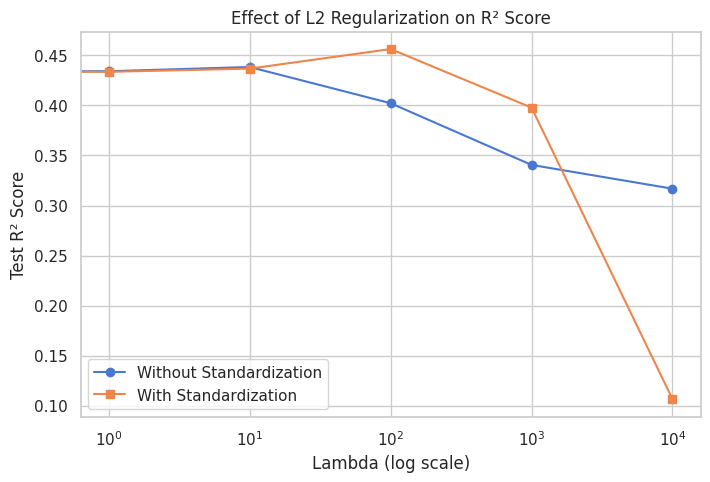

In [39]:
lambdas = [0, 1, 10, 100, 1000, 10000]
r2_raw, r2_std = [], []

for lam in lambdas:
    # Without standardization
    theta_raw = closed_form_theta(X_train_b, y_train, l2=lam)
    pred_raw  = X_test_b @ theta_raw
    r2_raw.append(r2(y_test, pred_raw))
    
    # With standardization
    theta_std = closed_form_theta(X_train_b_s, y_train, l2=lam)
    pred_std  = X_test_b_s @ theta_std
    r2_std.append(r2(y_test, pred_std))

# Plot R2 vs Lambda
plt.figure(figsize=(8,5))
plt.plot(lambdas, r2_raw, marker="o", label="Without Standardization")
plt.plot(lambdas, r2_std, marker="s", label="With Standardization")
plt.xscale("log")
plt.xlabel("Lambda (log scale)")
plt.ylabel("Test R² Score")
plt.title("Effect of L2 Regularization on R² Score")
plt.legend()
plt.grid(True)
plt.show()


### Predicted vs actual plot for both with and without standardization

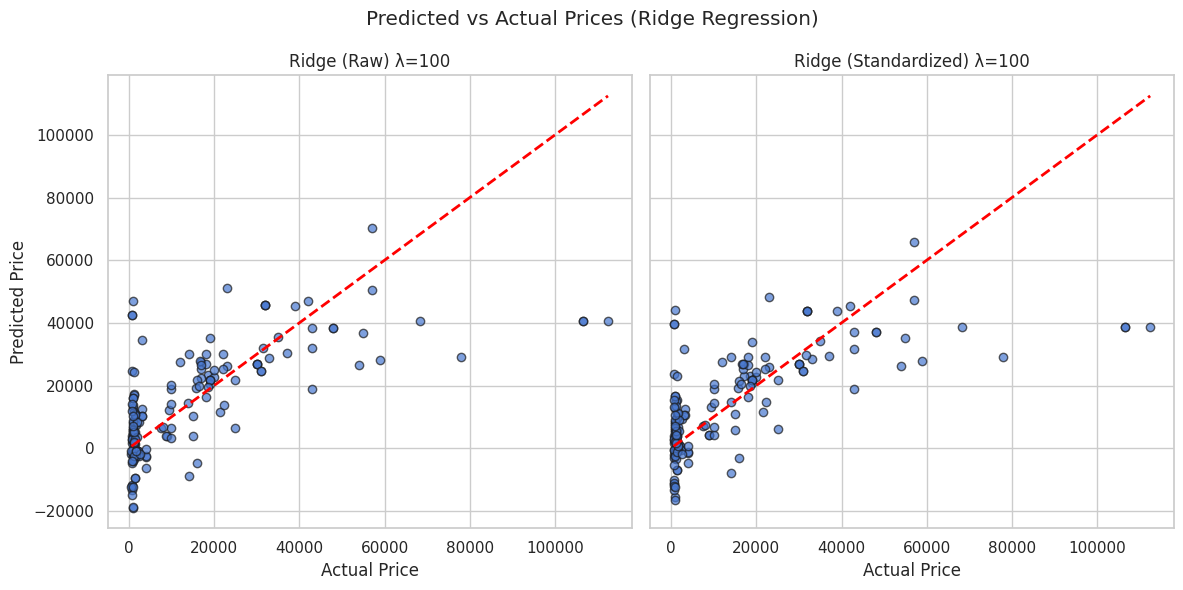

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12,6), sharey=True)

# --- Without Standardization ---
axes[0].scatter(y_test, y_pred_test_cf_l2_raw, alpha=0.7, edgecolor='k')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linestyle='--', linewidth=2)  # ideal line
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title(f"Ridge (Raw) λ={l2_lambda}")

# --- With Standardization ---
axes[1].scatter(y_test, y_pred_test_cf_l2_std, alpha=0.7, edgecolor='k')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel("Actual Price")
axes[1].set_title(f"Ridge (Standardized) λ={l2_lambda}")

plt.suptitle("Predicted vs Actual Prices (Ridge Regression)")
plt.tight_layout()
plt.show()


### Predicted vs actual plot for different lambda values

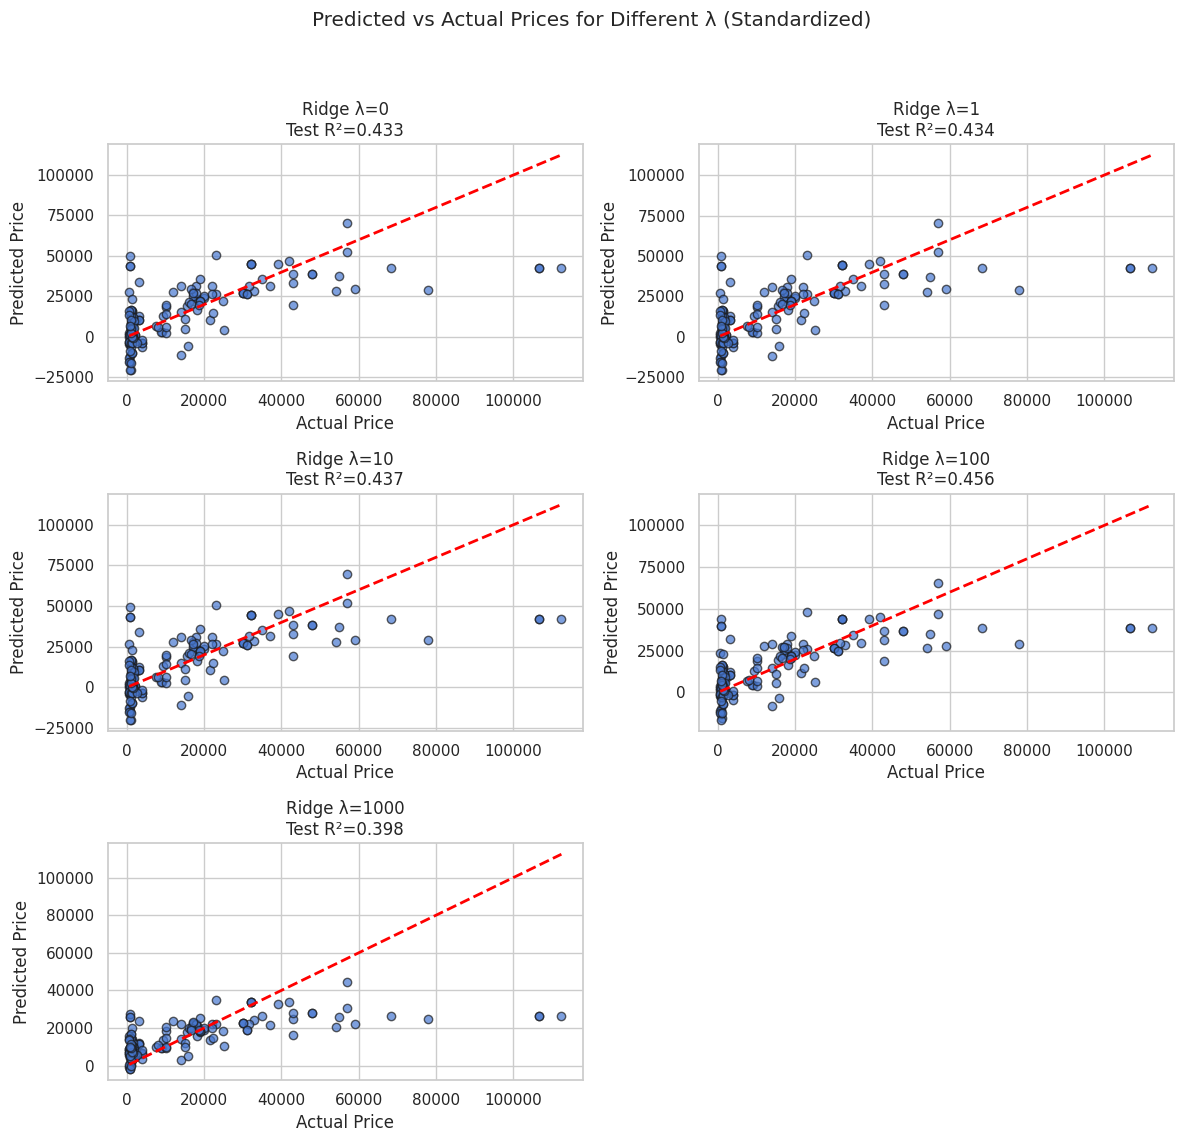

In [44]:
lambdas = [0, 1, 10, 100, 1000]  # choose your lambda values
n_lambda = len(lambdas)

# Prepare subplots (adjust rows/cols for better layout)
rows = (n_lambda + 1) // 2
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))
axes = axes.flatten()

for i, lam in enumerate(lambdas):
    # Compute theta for current lambda
    theta_l2 = closed_form_theta(X_train_b_s, y_train, l2=lam)
    
    # Predict on test set
    y_pred_test_l2 = X_test_b_s @ theta_l2
    
    # Scatter plot Predicted vs Actual
    axes[i].scatter(y_test, y_pred_test_l2, alpha=0.7, edgecolor='k')
    axes[i].plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()],
                 color='red', linestyle='--', linewidth=2)
    axes[i].set_xlabel("Actual Price")
    axes[i].set_ylabel("Predicted Price")
    axes[i].set_title(f"Ridge λ={lam}\nTest R²={r2(y_test, y_pred_test_l2):.3f}")

# Hide any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Predicted vs Actual Prices for Different λ (Standardized)")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Feature importance with l2 weights

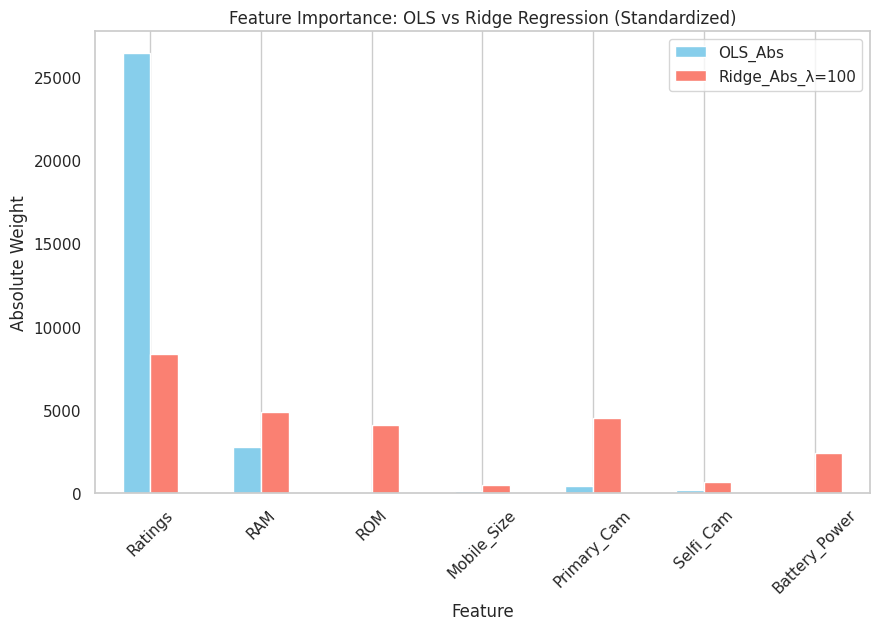

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Feature names
feature_names = ["Ratings", "RAM", "ROM", "Mobile_Size", "Primary_Cam", "Selfi_Cam", "Battery_Power"]
l2_lambda = 100

# --- Weights ---
weights_ols  = theta_cf[1:].flatten()         # Skip bias
weights_ridge = theta_cf_l2_std[1:].flatten()

# Create DataFrame
feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "OLS_Abs": np.abs(weights_ols),
    f"Ridge_Abs_λ={l2_lambda}": np.abs(weights_ridge)
}).set_index("Feature")

# Plot side by side
feat_imp_df.plot(kind="bar", figsize=(10,6), color=["skyblue", "salmon"])
plt.ylabel("Absolute Weight")
plt.title("Feature Importance: OLS vs Ridge Regression (Standardized)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()
